## Introduction
In this project, I will investigate a 2020 flood in Uzbekistan and Kazakhstan and assess the area of the land affected by the flood by the land use type.

On May 1, 2020, the Sardoba reservoir dam in Uzbekistan collapsed, releasing approximately 500 million m³ of water. The resulting flood affected the Syrdarya River basin, causing six deaths and displacing over 100,000 people.

The most affected areas were the Sirdaryo Region of Uzbekistan and the Turkistan Region of Kazakhstan. The flood had significant economic implications, particularly for agriculture.

In 2022, Turkistan accounted for ~11% of Kazakhstan's agricultural output.

Sirdaryo contributes ~3% of Uzbekistan’s agricultural output.

This analysis aims to estimate the extent and type of land use affected by the flood, using satellite-derived land cover and water presence datasets.

![Mirzaabad flooding](/images/Mirzaabad_flood.gif)
*Flood in Mirzaabad District*
[Side-by-side slider](https://iv-div.github.io/my-jupyter-portfolio/Syrdarya_flood/side_by_side/)

## Data Sources
Land Use: [Copernicus Global Land Cover 2019](https://doi.org/10.2909/c6377c6e-76cc-4d03-8330-628a03693042)
Resolution: 100m x 100m
Format: 23 classes based on the FAO LCCS system.

Water (Flood Extent): JRC Global Surface Water (GSW)
Product: Monthly Water History
Resolution: 30m x 30m
Format: 2 classes: 1 = Not water, 2 = Water

Time period: Compare May 2020 and May 2021 with baseline years (May 2017, May 2018, May 2019).

## Important Data Limitation
The flood damage layers for Sirdarya in this study are derived from the JRC Global Surface Water (GSW) Monthly History dataset, which is based on classifications from cloud-free Landsat observations. Several technical factors limit its ability to fully capture the May 2020 flood event:

The Monthly History dataset provides a single classification for the entire month, based on available cloud-free scenes. It is derived from images taken by Landsat 7 and Landsat 8 satellites, each of which has a 16-day revisit cycle. Landsat 8 was offset 8 days from Landsat 7, so that under ideal conditions, the image is taken once every 8 days. A flood that ocurred after the collapse of the dam could in some areas last hours and days, and thus avoid being captured by the satellites.

Additionally, if the cloud cover or haze persisted during the critical days of the flood, these images would not be included in the creation of the classification, additionally causing underestimation of inundated areas

Due to these limitations, the detected flood extent for May 2020 in Sirdarya should be considered a minimum estimate. The actual area affected by flooding was likely larger, and particularly for a flash flood event, a substantial portion of the damage may not have been recorded in the satellite-derived dataset.

## Analysis
### Step 1. Area of interest
I download the shapefiles for [Uzbekistan](https://data.humdata.org/dataset/geoboundaries-admin-boundaries-for-uzbekistan) and [Kazakhstan](https://data.humdata.org/dataset/cod-ab-kaz) admin1 and 2 borders from HDX, and created a joint shapefile for the Sirdaryo Region of Uzbekistan and Turkistan Region of Kazakhstan. I uploaded this shapefile to GEE to clip the data sources according to my area of Interest.

Note: in the Uzbekistan shapefile, the ADM2 borders don't perfectly match the ADM1 border of the Sirdaryo Region. This will lead to some minor discrepancies (e.g. the areas of the ADM2 subregions wouldn't sum exactly to the ADM1 region's area).

 ![AOI with administrative borders](/images/AOI_administrative_borders.png)
*Area of interest with administrative borders. Background map: OpenStreet Map*

 ![Sirdaryo region with administrative borders](/images/Sirdaryo_region.png)
*Notice the discrepancies in the Uzbekistan shapefile ADM2 and ADM1 borders*

### Step 2. Land use and water data

All layers are processed at 30-meter resolution and projected in EPSG:32642 (UTM Zone 42N), which is appropriate for the Syrdarya region.

Land Use Data
I use the Copernicus Global Land Cover 2019 dataset, which provides detailed land cover classification at a native resolution of 100×100 meters. To match the resolution of the water data and support pixel-wise overlay analysis, I resample the land cover layer to 30-meter resolution using nearest-neighbor interpolation.
The resulting land cover raster is clipped to the area of interest and exported.

Surface Water Data
To isolate areas flooded due to the dam collapse, rather than normal seasonal water presence, I use the following approach:

Baseline Water Mask (May 2017–2019)
I create a composite mask of water presence during the month of May in 2017, 2018, or 2019. Pixels with water (2) in any of those years are considered part of the regular seasonal regime.

Missing pixels are unmasked to 0 to ensure full spatial coverage.

2020 Flood Layer
I compare the May 2020 water map to the historical mask.

Pixels are marked as flooded if they had water in May 2020 but not in any of the baseline years.

Missing pixels in the 2020 map are also unmasked to 0 to avoid dropping data.

2021 Post-Restoration Layer
To assess the effect of the dam's reported restoration (announced in February 2021), I repeat the comparison using the May 2021 map.

This helps identify areas that remained anomalously inundated after one year.

All binary water change layers are masked to show only newly inundated areas (selfMask()), and exported at 30-meter resolution in EPSG:32642, ready for analysis in QGIS.



In [ ]:
// Note: this code is for GEE (https://code.earthengine.google.com/)
// ---------------------------
// 1. Define AOI
// ---------------------------
var aoi = ee.FeatureCollection('projects/flood-hotspot/assets/Syrdarya');
Map.centerObject(aoi, 8);

// ---------------------------
// 2. Load and Export Land Cover 2019 (Resampled to 30m)
// ---------------------------
var landcoverRaw = ee.ImageCollection('COPERNICUS/Landcover/100m/Proba-V-C3/Global')
  .filterDate('2019-01-01', '2020-01-01')
  .first()
  .select('discrete_classification')
  .clip(aoi);

// Mask out class 0
var landcover = landcoverRaw.updateMask(landcoverRaw.neq(0));

// Reproject to 30m using nearest-neighbor resampling
var landcover30m = landcover.reproject({
  crs: 'EPSG:32642',
  scale: 30
});

// Optional visualization
Map.addLayer(landcover30m, {
  min: 1, max: 100,
  palette: ['#ffffcc', '#a1dab4', '#41b6c4', '#2c7fb8', '#253494']
}, 'Land Cover 2019 (30m)');

// Export the reprojected image
Export.image.toDrive({
  image: landcover30m,
  description: 'syrdarya_landcover_2019_resampled_30m',
  folder: 'work_folder/2025_SATGPT/Kazakhstan_floods',
  fileNamePrefix: 'syrdarya_landcover_2019_30m',
  region: aoi.geometry(),
  scale: 30,
  crs: 'EPSG:32642',
  maxPixels: 1e13
});


// ---------------------------
// 3. Load Water Mask for May in Each Year
// ---------------------------
function getMayWater(year) {
  return ee.ImageCollection('JRC/GSW1_4/MonthlyHistory')
    .filterDate(year + '-05-01', year + '-06-01')
    .first()
    .select('water')
    .clip(aoi);
}

var water2017 = getMayWater(2017);
var water2018 = getMayWater(2018);
var water2019 = getMayWater(2019);
var water2020 = getMayWater(2020);
var water2021 = getMayWater(2021);

// ---------------------------
// 4. Create Damage Layers
// ---------------------------
var historical = water2017.unmask(0)
  .max(water2018.unmask(0))
  .max(water2019.unmask(0));

var damage2020 = water2020.unmask(0)
  .eq(2)                      // Water in May 2020
  .and(historical.neq(2))     // But not in previous years
  .rename('flood')
  .uint8();                   // Convert to 8-bit integer (values 0 or 1)
var lastingDamage2021 = water2021.unmask(0)
  .eq(2)
  .and(historical.neq(2))
  .rename('flood')
  .uint8();

Map.addLayer(damage2020, {min: 0, max: 1, palette: ['white', 'red']}, 'Flood 2020 (binary)');
Map.addLayer(lastingDamage2021, {min: 0, max: 1, palette: ['white', 'purple']}, 'Flood 2021 (binary)');

// ---------------------------
// 5. Export Damage Layers at 30m in EPSG:32642
// ---------------------------
Export.image.toDrive({
  image: damage2020,
  description: 'syrdarya_damage_2020',
  folder: 'work_folder/2025_SATGPT/Kazakhstan_floods',
  fileNamePrefix: 'syrdarya_damage_2020',
  region: aoi.geometry(),
  scale: 30,
  crs: 'EPSG:32642',
  maxPixels: 1e13
});

Export.image.toDrive({
  image: lastingDamage2021,
  description: 'syrdarya_lasting_damage_2021',
  folder: 'work_folder/2025_SATGPT/Kazakhstan_floods',
  fileNamePrefix: 'syrdarya_lasting_damage_2021',
  region: aoi.geometry(),
  scale: 30,
  crs: 'EPSG:32642',
  maxPixels: 1e13
});


### Step 3. Descriptive statistics of the land use

I count the pixels in each polygon to obtain information about the land use.

In [ ]:
# this code is to be run in QGIS Python console
import processing
from qgis.PyQt.QtCore import QVariant
from collections import defaultdict

# Load your layers
vector_layer = QgsProject.instance().mapLayersByName("Sirdarya_AOI")[0]
raster_layer = QgsProject.instance().mapLayersByName("syrdarya_landcover_2019_30m")[0]

# Temporary output for zonal histogram
zonal_output = '/tmp/zonal_stats_output.gpkg'

# Run Zonal Histogram (counts pixels per land cover class)
processing.run("qgis:zonalhistogram", {
    'INPUT_RASTER': raster_layer,
    'RASTER_BAND': 1,
    'INPUT_VECTOR': vector_layer,
    'COLUMN_PREFIX': 'lc_',
    'OUTPUT': zonal_output
})

# Load the result
zonal_result = QgsVectorLayer(zonal_output, "zonal_stats", "ogr")

# Calculate per-region land cover stats
results = []

for feature in zonal_result.getFeatures():
    region = feature["ADM1_EN"]
    subregion = feature["ADM2_EN"]
    region_id = subregion if subregion else region

    # Collect land cover classes from prefixed fields
    for field in zonal_result.fields():
        if field.name().startswith("lc_"):
            class_id = int(field.name().split("_")[1])
            pixel_count = feature[field.name()]
            if pixel_count and pixel_count > 0:
                area_ha = pixel_count * 0.09  # 30m x 30m = 0.09 ha
                results.append({
                    'region_id': region_id,
                    'landcover_class': class_id,
                    'area_ha': area_ha
                })

# Convert results to a CSV or print summary
import csv

output_path = '' # add output path
with open(output_path, 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=['region_id', 'landcover_class', 'area_ha'])
    writer.writeheader()
    for row in results:
        writer.writerow(row)

print(f"✅ Done! Results saved to {output_path}")


![Land use map](/images/AOI_landuse.png)
*Land use map of our region of interest*

To see the descriptive statistics of the land use for our Area of Interest, run the following snippet: 

In [38]:
import pandas as pd
from IPython.display import display, HTML

# === STEP 1: Load the CSV ===
csv_path = '/data-sources/land_use_stat.csv'
df = pd.read_csv(csv_path)

# === STEP 2: Create final region identifier ===
df['region_id'] = df['region_id'].fillna('')
df['region_id'] = df['region_id'].replace('', pd.NA)

# === STEP 3: Define land cover class labels ===
landcover_mapping = {
    0: 'No Data',
    20: 'Shrubland',
    30: 'Grassland',
    40: 'Cropland',
    50: 'Built-up',
    60: 'Bare/Sparse Vegetation',
    70: 'Snow and Ice',
    80: 'Permanent Water Bodies',
    90: 'Herbaceous Wetland',
    111: 'Closed Forest, Evergreen Needle Leaf',
    113: 'Closed Forest, Deciduous Broad Leaf',
    116: 'Open Forest, Evergreen Broad Leaf',
    123: 'Open Forest, Deciduous Broad Leaf',
    126: 'Mosaic Forest'
}

# Filter relevant classes
df = df[df['landcover_class'].isin(landcover_mapping.keys())]
df['landcover_class'] = df['landcover_class'].map(landcover_mapping)

# === STEP 4: Pivot to wide table ===
pivot = df.pivot_table(
    index='region_id',
    columns='landcover_class',
    values='area_ha',
    aggfunc='sum',
    fill_value=0
)
pivot['Total'] = pivot.sum(axis=1)

# === STEP 5: Custom row order ===
row_order = [
    # Group 1
    "Akaltin", "Bayaut", "Gulistan", "Gulistan city", "Khavas",
    "Mirzaabad", "Sardoba", "Saykhunabad", "Shirin city",
    "Sirdarya", "Yangiyer city", "Sirdaryo Region",
    # Group 2
    "Arys", "Baydibek", "Kazygurt", "Keles", "Kentau",
    "Maktaaral", "Ordabasy", "Otyrar", "Saryagash",
    "Sayram", "Shardara", "Sozak", "Tole Bi", "Tulkibas",
    "Turkestan", "Zhetisay", "Turkistan Region"
]
pivot = pivot.rename(index=lambda x: str(x).replace(" District", ""))
pivot = pivot.reindex(row_order)

# === STEP 6: Custom column order ===
col_order = [
    "Grassland", "Cropland", "Shrubland", "Bare/Sparse Vegetation",
    "Herbaceous Wetland", "Permanent Water Bodies", "Built-up",
    "Snow and Ice", "Closed Forest, Evergreen Needle Leaf",
    "Closed Forest, Deciduous Broad Leaf", "Open Forest, Evergreen Broad Leaf",
    "Open Forest, Deciduous Broad Leaf", "Mosaic Forest", "No Data", "Total"
]
pivot = pivot[[c for c in col_order if c in pivot.columns]]

# === STEP 7: Rename index ===
pivot.index.name = "Region/District"

# === STEP 8: Style groups ===
group1 = row_order[:12]
group2 = row_order[12:]

def highlight_groups(row):
    if row.name in group1:
        return ['background-color: #f0f0f0'] * len(row)  # light gray
    elif row.name in group2:
        return ['background-color: #e6f2ff'] * len(row)  # light blue
    return [''] * len(row)

styled = pivot.round(0).astype(int).style.apply(highlight_groups, axis=1)

# === STEP 9: Display with big title ===
display(HTML("<h2>Landuse (in ha)</h2>"))
display(styled)


landcover_class,Grassland,Cropland,Shrubland,Bare/Sparse Vegetation,Herbaceous Wetland,Permanent Water Bodies,Built-up,Snow and Ice,"Closed Forest, Evergreen Needle Leaf","Closed Forest, Deciduous Broad Leaf","Open Forest, Evergreen Broad Leaf","Open Forest, Deciduous Broad Leaf",Mosaic Forest,No Data,Total
Region/District,,,,,,,,,,,,,,,
Akaltin,855,62385,341,0,65,78,1050,0,0,0,0,0,1,0,64775
Bayaut,2507,32309,1666,6,233,207,3237,0,0,0,4,0,11,0,40179
Gulistan,714,29725,258,2,192,35,4673,0,0,0,0,0,9,0,35608
Gulistan city,118,697,72,0,0,0,674,0,0,0,0,0,0,0,1561
Khavas,11861,43852,3776,170,498,1129,4018,0,0,0,0,0,4,0,65308
Mirzaabad,22760,44596,8491,147,1492,3747,2591,0,0,0,12,0,6,0,83843
Sardoba,6626,45651,1729,30,260,584,1024,0,0,0,1,0,18,0,55921
Saykhunabad,1171,38646,353,20,430,95,2638,0,0,0,101,0,177,0,43632
Shirin city,0,13,0,0,0,0,0,0,0,0,0,0,0,0,13


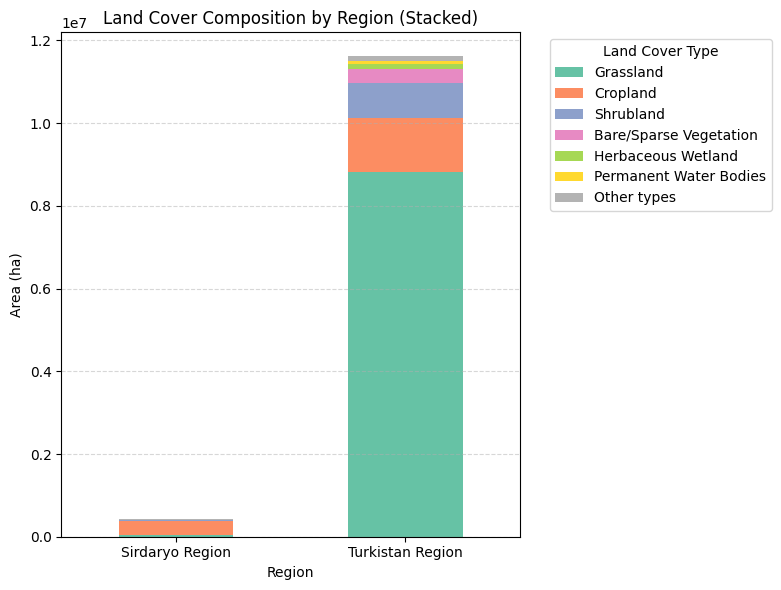

In [46]:
import matplotlib.pyplot as plt

# === Step 1: Define stacking order and groupings ===
stack_order = [
    'Grassland',
    'Cropland',
    'Shrubland',
    'Bare/Sparse Vegetation',
    'Herbaceous Wetland',
    'Permanent Water Bodies'
]

# Create a new column for 'Other types'
landcover_cols = [col for col in pivot.columns if col != 'Total']
other_types = [col for col in landcover_cols if col not in stack_order]

# Copy relevant rows and add 'Other types' column
regions_of_interest = ['Sirdaryo Region', 'Turkistan Region']
data = pivot.loc[regions_of_interest].copy()

# Create 'Other types' column
data['Other types'] = data[other_types].sum(axis=1)

# Select only the desired columns in the specified order
final_columns = stack_order + ['Other types']
plot_data = data[final_columns]  # Keep hectares, no conversion

# === Step 2: Plot stacked bar chart ===
ax = plot_data.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    color=[
        '#66c2a5',  # Grassland
        '#fc8d62',  # Cropland
        '#8da0cb',  # Shrubland
        '#e78ac3',  # Bare/Sparse Vegetation
        '#a6d854',  # Herbaceous Wetland
        '#ffd92f',  # Permanent Water Bodies
        '#b3b3b3'   # Other types
    ]
)

# === Step 3: Final formatting ===
plt.ylabel('Area (ha)')
plt.xlabel('Region')
plt.title('Land Cover Composition by Region (Stacked)')
plt.xticks(rotation=0)
plt.legend(title='Land Cover Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Most of Sirdaryo Region is cropland, while over 75% of Turkistan Region is grassland

### Step 4. Descriptive statistics of water damage

I count the pixels of the syrdarya_damage_2020 and syrdarya_lasting_damage_2021 layers for each polygon to obtain information about the area of inundation, using the Zonal histogram tool. I add this information to the original vector layer (using the Join attributes by field value and Field calculator tools) to visualise which regions were mostly affected by the flood. I subsequently calculate the area of the regions, using the Add geometry attributes tool) to get the relative damaged area.

![Districts by flooding area](/images/AOI_flooded_area.png)
*Districts by flooding area*

In [12]:
import pandas as pd
from IPython.display import display

# Load the CSV
csv_path = '/data-sources/flooded_area.csv'
df = pd.read_csv(csv_path)

# Keep only relevant columns
df = df[['ADM1_EN', 'ADM2_EN', '2020_flooded_area_ha', '2021_flooded_area_ha']]

# Ensure flood area columns are numeric
df['2020_flooded_area_ha'] = pd.to_numeric(df['2020_flooded_area_ha'], errors='coerce')
df['2021_flooded_area_ha'] = pd.to_numeric(df['2021_flooded_area_ha'], errors='coerce')

# Create a flag to identify ADM2 summary rows (where ADM2_EN is null)
df['ADM2_EN_null_flag'] = df['ADM2_EN'].isnull()

# Sort: within each ADM1_EN, sort by 2020 area; put summary rows (null ADM2_EN) last
df = df.sort_values(by=['ADM1_EN', 'ADM2_EN_null_flag', '2020_flooded_area_ha'])

# Replace NaN with 'Total' (after sorting to preserve logic)
df['ADM2_EN'] = df['ADM2_EN'].fillna('Total')

# Drop the sorting flag
df = df.drop(columns='ADM2_EN_null_flag').reset_index(drop=True)

# Highlight the 'Total' rows
def highlight_summary(row):
    if row['ADM2_EN'] == 'Total':
        return ['background-color: #f9f9a9'] * len(row)
    else:
        return [''] * len(row)

# Format and display
styled = df.style \
    .format({'2020_flooded_area_ha': '{:,.2f}', '2021_flooded_area_ha': '{:,.2f}'}) \
    .apply(highlight_summary, axis=1) \
    .set_properties(**{'text-align': 'left'}) \
    .set_table_styles([dict(selector='th', props=[('text-align', 'left')])])

display(styled)


,ADM1_EN,ADM2_EN,2020_flooded_area_ha,2021_flooded_area_ha
0,Sirdaryo Region,Shirin city,0.00,0.00
1,Sirdaryo Region,Yangiyer city,0.00,0.00
2,Sirdaryo Region,Gulistan city,4.00,1.00
3,Sirdaryo Region,Khavas,20.00,80.00
4,Sirdaryo Region,Gulistan,87.00,124.00
5,Sirdaryo Region,Bayaut,116.00,296.00
6,Sirdaryo Region,Saykhunabad,133.00,247.00
7,Sirdaryo Region,Sardoba,134.00,196.00
8,Sirdaryo Region,Akaltin,201.00,134.00
9,Sirdaryo Region,Sirdarya,264.00,490.00


We see that the most affected districts are Mirzaabad, Sirdarya and Akaltin in Sirdaryo Region and Sozak, Shardara and Maktaaral Districts in Turkistan. We also see that the reconstruction of the dam, reported to have started in 2021, hasn't brought effect by May 2021: over 9 000 ha in two countries experienced exessive (relative to base water regime in 2017-2019) flooding.

### Step 5. Water damage by land type
To identify land type damaged by flooding, I multiply the flooding layer and the land use layer. Since flooded pixels have the value of 1, and non-flooded pixels have the value of 0, the resulting raster layer has non-zero pixels representing damaged areas only, keeping the land use values. I then apply the Zonal histogram from the Toolbox to count the number of pixels of each category within each polygon. I export this as a csv to visualise it here:

![Mirzaabad district](/images/Mirzaabad_flood_landuse.png)
*Mirzaabad district. Land use pixels represent flooded areas*

ADM1_EN,Cropland,Grassland,Bare / Sparse Vegetation,Herbaceous Wetland,Shrubland,Permanent Water Bodies,Built-up,Mosaic Forest,"Open Forest, Evergreen Broad Leaf"
Turkistan Region,"1,677.24",271.35,817.92,392.67,55.98,33.21,3.33,2.70,0.27
Sirdaryo Region,945.00,986.13,1.35,311.85,567.36,31.59,3.87,4.14,0.27
Total,"2,622.24","1,257.48",819.27,704.52,623.34,64.80,7.20,6.84,0.54


ADM1_EN,ADM2_EN,Cropland,Grassland,Bare / Sparse Vegetation,Herbaceous Wetland,Shrubland,Permanent Water Bodies,Built-up,Mosaic Forest,"Open Forest, Evergreen Broad Leaf"
Sirdaryo Region,Mirzaabad,644.58,827.01,0.81,210.24,518.58,24.66,0.45,0.90,0.00
Turkistan Region,Sozak,23.31,75.87,803.79,227.52,0.00,0.63,0.00,0.00,0.00
Turkistan Region,Shardara,697.32,53.28,1.53,90.27,15.21,8.19,1.26,1.98,0.09
Turkistan Region,Maktaaral,675.90,25.83,0.00,7.83,23.22,0.00,0.54,0.00,0.00
Sirdaryo Region,Sirdarya,217.35,2.70,0.00,40.77,0.45,0.81,0.00,1.98,0.09
Turkistan Region,Zhetisay,195.57,8.64,0.00,6.93,2.34,0.36,0.00,0.00,0.00
Sirdaryo Region,Akaltin,145.80,15.21,0.00,6.21,33.21,0.27,0.18,0.00,0.00
Sirdaryo Region,Sardoba,19.26,96.12,0.00,6.84,10.98,0.72,0.00,0.27,0.00
Sirdaryo Region,Saykhunabad,123.03,5.76,0.00,2.61,0.45,0.18,0.09,0.45,0.18
Sirdaryo Region,Bayaut,40.68,41.40,0.27,6.84,21.96,3.78,0.63,0.00,0.00


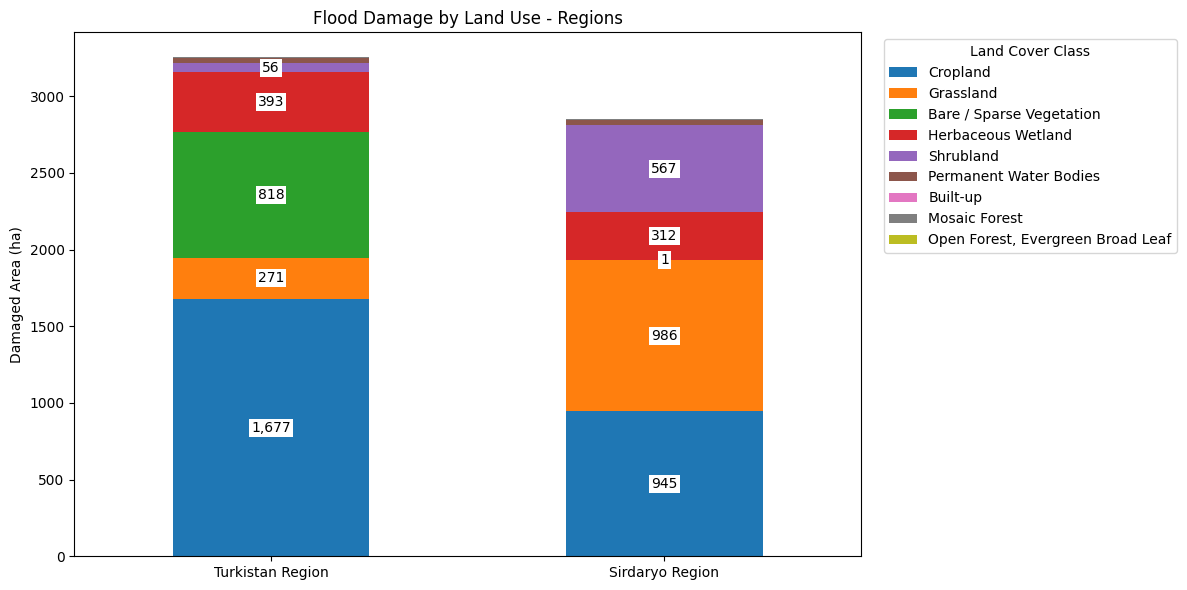

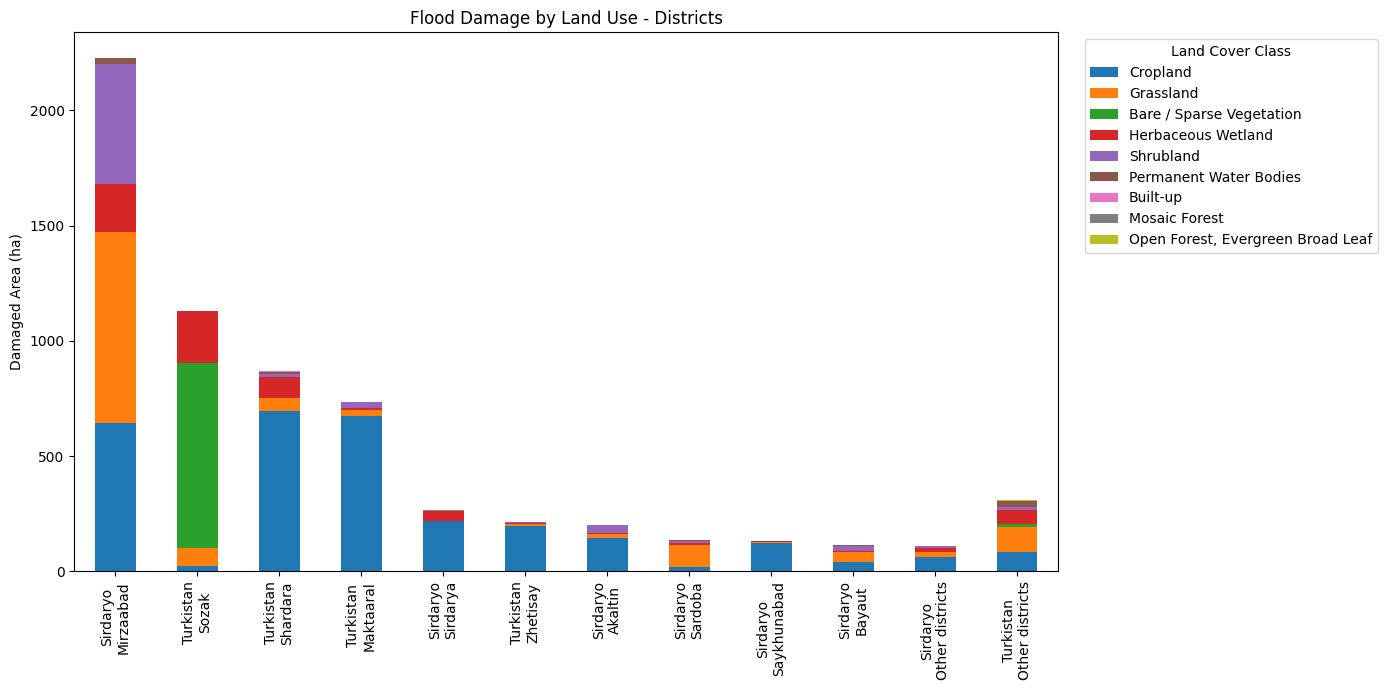

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# --- Load ---
csv_path = '/data-sources/damage_by_landcover.csv'
df = pd.read_csv(csv_path)

# Expected columns
base_cols = ['ADM1_EN', 'ADM2_EN']
damage_cols = ['damage_20','damage_30','damage_40','damage_50','damage_60',
               'damage_80','damage_90','damage_116','damage_126']

# Coerce damage columns to numeric and convert pixels → hectares
for c in damage_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0) * 0.09

# Strip "District" from ADM2_EN for display/plots
df['ADM2_EN'] = df['ADM2_EN'].astype('object')
df['ADM2_EN'] = df['ADM2_EN'].apply(lambda x: None if pd.isna(x) else str(x).replace('District','').strip())

# Rename damage columns to Copernicus class names
name_map = {
    'damage_20':  'Shrubland',
    'damage_30':  'Grassland',
    'damage_40':  'Cropland',
    'damage_50':  'Built-up',
    'damage_60':  'Bare / Sparse Vegetation',
    'damage_80':  'Permanent Water Bodies',
    'damage_90':  'Herbaceous Wetland',
    'damage_116': 'Open Forest, Evergreen Broad Leaf',
    'damage_126': 'Mosaic Forest'
}
pretty_cols = [name_map[c] for c in damage_cols]
df_pretty = df.rename(columns=name_map).copy()

# --- Split into two tables ---
t1 = df_pretty[df_pretty['ADM2_EN'].isna()].copy()
t2 = df_pretty[df_pretty['ADM2_EN'].notna()].copy()

# --- Table 1: Regions ---
t1_display = t1[['ADM1_EN'] + pretty_cols].copy()
col_order_t1 = t1_display[pretty_cols].sum(axis=0).sort_values(ascending=False).index.tolist()
t1_display = t1_display[['ADM1_EN'] + col_order_t1]

# Add Total row
total_row = pd.DataFrame([['Total'] + [t1_display[c].sum() for c in col_order_t1]],
                         columns=['ADM1_EN'] + col_order_t1)
t1_display = pd.concat([t1_display, total_row], ignore_index=True)

# --- Table 2: Districts ---
t2['_row_sum_'] = t2[pretty_cols].sum(axis=1)
col_order_t2 = t2[pretty_cols].sum(axis=0).sort_values(ascending=False).index.tolist()
t2_sorted = t2.sort_values('_row_sum_', ascending=False).drop(columns=['_row_sum_'])
t2_display = t2_sorted[['ADM1_EN', 'ADM2_EN'] + col_order_t2].reset_index(drop=True)

# --- Display tables ---
styler1 = (t1_display.style
           .format({c: '{:,.2f}' for c in col_order_t1})
           .set_caption('Region Damage by Land Use'))
try:
    display(styler1.hide(axis='index'))
except Exception:
    display(styler1.hide_index())

styler2 = (t2_display.style
           .format({c: '{:,.2f}' for c in col_order_t2})
           .set_caption('District Damage by Land Use'))
try:
    display(styler2.hide(axis='index'))
except Exception:
    display(styler2.hide_index())

# --- Chart 1: Regions ---
label_classes = {
    'Shrubland',
    'Grassland',
    'Cropland',
    'Bare / Sparse Vegetation',
    'Herbaceous Wetland'
}

fig1, ax1 = plt.subplots(figsize=(12, 6))
t1_plot = t1_display[t1_display['ADM1_EN'] != 'Total'].set_index('ADM1_EN')
t1_plot[col_order_t1].plot(kind='bar', stacked=True, ax=ax1)
ax1.tick_params(axis='x', labelrotation=0)

for series_name, container in zip(t1_plot[col_order_t1].columns, ax1.containers):
    if series_name in label_classes:
        labels = []
        for rect in container:
            height = rect.get_height()
            if height > 0:
                labels.append(f"{height:,.0f}")
            else:
                labels.append("")
        ax1.bar_label(
            container, labels=labels, label_type='center',
            color='black',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5)
        )

ax1.set_ylabel('Damaged Area (ha)')
ax1.set_xlabel('')
ax1.set_title('Flood Damage by Land Use - Regions')
ax1.legend(title='Land Cover Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Chart 2: Districts ---
keep_pairs = {
    ('Sirdaryo Region', 'Mirzaabad'),
    ('Turkistan Region', 'Sozak'),
    ('Turkistan Region', 'Shardara'),
    ('Turkistan Region', 'Maktaaral'),
    ('Sirdaryo Region', 'Sirdarya'),
    ('Turkistan Region', 'Zhetisay'),
    ('Sirdaryo Region', 'Akaltin'),
    ('Sirdaryo Region', 'Sardoba'),
    ('Sirdaryo Region', 'Saykhunabad'),
    ('Sirdaryo Region', 'Bayaut'),
}

t2_keep = t2_display[
    t2_display.apply(lambda r: (r['ADM1_EN'], r['ADM2_EN']) in keep_pairs, axis=1)
].copy()

t2_other = t2_display[
    ~t2_display.apply(lambda r: (r['ADM1_EN'], r['ADM2_EN']) in keep_pairs, axis=1)
].copy()

other_rows = []
for region in ['Sirdaryo Region', 'Turkistan Region']:
    tmp = t2_other[t2_other['ADM1_EN'] == region]
    if len(tmp) > 0:
        summed = tmp[col_order_t2].sum().to_dict()
        row = {'ADM1_EN': region, 'ADM2_EN': 'Other districts'}
        row.update(summed)
        other_rows.append(row)

t2_chart_df = pd.concat([t2_keep, pd.DataFrame(other_rows)], ignore_index=True)

t2_chart_df_mod = t2_chart_df.copy()
t2_chart_df_mod['ADM1_EN'] = t2_chart_df_mod['ADM1_EN'].str.replace(' Region', '', regex=False)
t2_chart_df_mod['Label'] = (
    t2_chart_df_mod['ADM1_EN'].astype(str) + '\n' + t2_chart_df_mod['ADM2_EN'].astype(str)
)

fig2, ax2 = plt.subplots(figsize=(14, 7))
plot_df = t2_chart_df_mod.set_index('Label')[col_order_t2]
plot_df.plot(kind='bar', stacked=True, ax=ax2)

ax2.set_ylabel('Damaged Area (ha)')
ax2.set_xlabel('')
ax2.set_title('Flood Damage by Land Use - Districts')
ax2.legend(title='Land Cover Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


The data shows us that the flood damaged similar areas of land in both countries: over 3250 ha in Kazakhstan and over 2850 ha in Uzbekistan. The composition of the affected land shows that in Uzbekistan the flood damaged equally grassland and cropland, while in Kazakhstan the damage to cropland was smaller, reflecting the overall proportion of the land use in these two regions.